In [1]:
import numpy as np

In [2]:
Ebasic = np.array([[1, 0 , 0],
                    [0, 1, 0],
                    [0, 0, 1],
                    [0, 0, 0]])

In [3]:
from sympy import Matrix, latex, nsimplify
from IPython.display import display, Math

In [4]:
def display_matrix(matrix):
    expr = Matrix((matrix).tolist())
    display(Math(latex(expr)))

In [5]:
display_matrix(Ebasic)

<IPython.core.display.Math object>

In [6]:
def validate_encoding_map(E: np.ndarray, tol: float = 1e-10) -> dict:
    """
    Sprawdza, czy macierz E jest poprawną mapą kodowania qutrytu w 2 kubity.

    Matematyczne warunki poprawności:
    ----------------------------------
    E: C^3 -> C^4  (wymiar: 4x3)

    1. Izometria:        E† E = I_3
       - każda kolumna ma normę 1 (kolumny znormalizowane),
       - różne kolumny są ortogonalne.

    2. Projektor na podprzestrzeń kodową:  P = E E†  (wymiar 4x4)
       - hermitowskość:    P† = P,
       - idempotentność:   P² = P.

    Warunki (1) i (2) są równoważne dla izometrii; sprawdzamy oba dla pełności.
    """

    result = {
        "is_valid":             False,
        "correct_shape":        False,
        "columns_normalized":   False,
        "columns_orthogonal":   False,
        "is_isometry":          False,
        "projector_hermitian":  False,
        "projector_idempotent": False,
        "rank":                 None,
        "message":              "",
    }

    # --- 1. Sprawdzenie kształtu ---
    if E.shape != (4, 3):
        result["correct_shape"] = False
        result["message"] = (
            f"Niepoprawny wymiar macierzy: {E.shape}. Oczekiwano (4, 3)."
        )
        return result

    result["correct_shape"] = True

    # --- 2. Rząd macierzy ---
    result["rank"] = int(np.linalg.matrix_rank(E, tol=tol))

    # --- 3. Sprawdzenie kolumn ---
    # Gram matrix: G = E† E  (powinna być I_3)
    G = E.conj().T @ E

    # Normy kolumn: diagonala G powinna być [1, 1, 1]
    col_norms_ok = np.allclose(np.diag(G), np.ones(3), atol=tol)
    result["columns_normalized"] = bool(col_norms_ok)

    # Ortogonalność: poza diagonalą G powinna być zerowa
    off_diag = G - np.diag(np.diag(G))
    cols_ortho_ok = np.allclose(off_diag, 0, atol=tol)
    result["columns_orthogonal"] = bool(cols_ortho_ok)

    # --- 4. Sprawdzenie izometrii: E† E = I_3 ---
    isometry_ok = np.allclose(G, np.eye(3), atol=tol)
    result["is_isometry"] = bool(isometry_ok)

    # --- 5. Projektor P = E E† ---
    P = E @ E.conj().T

    # Hermitowskość: P† = P
    hermitian_ok = np.allclose(P, P.conj().T, atol=tol)
    result["projector_hermitian"] = bool(hermitian_ok)

    # Idempotentność: P² = P
    idempotent_ok = np.allclose(P @ P, P, atol=tol)
    result["projector_idempotent"] = bool(idempotent_ok)

    # --- 6. Ogólna ocena ---
    all_ok = (
        isometry_ok
        and hermitian_ok
        and idempotent_ok
    )
    result["is_valid"] = bool(all_ok)

    if all_ok:
        result["message"] = "E jest poprawną mapą kodowania (izometrią)."
    else:
        issues = []
        if not col_norms_ok:
            issues.append("kolumny nie są znormalizowane")
        if not cols_ortho_ok:
            issues.append("kolumny nie są ortogonalne")
        if not hermitian_ok:
            issues.append("P = EE† nie jest hermitowskie")
        if not idempotent_ok:
            issues.append("P = EE† nie jest idempotentne (P²≠P)")
        result["message"] = "Niepoprawna mapa kodowania: " + "; ".join(issues) + "."

    return result


# ============================================================
# PRZYKŁADY UŻYCIA
# ============================================================

if __name__ == "__main__":

    np.set_printoptions(precision=4, suppress=True)

    # --- Przykład 1: Poprawna mapa kodowania ---
    # Bierzemy pierwsze 3 kolumny macierzy unitarnej 4x4 (np. macierz Hadamarda 4x4)
    H4 = np.array([
        [1,  1,  1,  1],
        [1, -1,  1, -1],
        [1,  1, -1, -1],
        [1, -1, -1,  1],
    ], dtype=complex) / 2.0

    E_valid = H4[:, :3]  # pierwsze 3 kolumny → izometria

    print("=" * 50)
    print("Przykład 1: Poprawna mapa kodowania")
    print("=" * 50)
    res1 = validate_encoding_map(E_valid)
    for k, v in res1.items():
        print(f"  {k:25s}: {v}")

    # --- Przykład 2: Niepoprawna mapa kodowania ---
    # Macierz 4x3 z losowymi (niezortonormalizowanymi) kolumnami
    rng = np.random.default_rng(42)
    E_invalid = rng.standard_normal((4, 3)) + 1j * rng.standard_normal((4, 3))

    print()
    print("=" * 50)
    print("Przykład 2: Niepoprawna mapa kodowania (losowa)")
    print("=" * 50)
    res2 = validate_encoding_map(E_invalid)
    for k, v in res2.items():
        print(f"  {k:25s}: {v}")

Przykład 1: Poprawna mapa kodowania
  is_valid                 : True
  correct_shape            : True
  columns_normalized       : True
  columns_orthogonal       : True
  is_isometry              : True
  projector_hermitian      : True
  projector_idempotent     : True
  rank                     : 3
  message                  : E jest poprawną mapą kodowania (izometrią).

Przykład 2: Niepoprawna mapa kodowania (losowa)
  is_valid                 : False
  correct_shape            : True
  columns_normalized       : False
  columns_orthogonal       : False
  is_isometry              : False
  projector_hermitian      : True
  projector_idempotent     : False
  rank                     : 3
  message                  : Niepoprawna mapa kodowania: kolumny nie są znormalizowane; kolumny nie są ortogonalne; P = EE† nie jest idempotentne (P²≠P).


In [7]:
Enew = np.array([[0, 0, 0],
                [1, 0, 0],
                [0, 1, 0],
                [0, 0, 1]])

validate_encoding_map(Enew)

{'is_valid': True,
 'correct_shape': True,
 'columns_normalized': True,
 'columns_orthogonal': True,
 'is_isometry': True,
 'projector_hermitian': True,
 'projector_idempotent': True,
 'rank': 3,
 'message': 'E jest poprawną mapą kodowania (izometrią).'}

In [8]:
W = Enew @ Enew.conj().T

In [9]:
display_matrix(W)

<IPython.core.display.Math object>

In [10]:
a = 1/np.sqrt(2)

Ebell = np.array([[a, a, 0],
                [a, -a, 0],
                [0, 0, a],
                [0, 0, -a]])

display_matrix(Ebell)

<IPython.core.display.Math object>

In [11]:
validate_encoding_map(Ebell)

{'is_valid': True,
 'correct_shape': True,
 'columns_normalized': True,
 'columns_orthogonal': True,
 'is_isometry': True,
 'projector_hermitian': True,
 'projector_idempotent': True,
 'rank': 3,
 'message': 'E jest poprawną mapą kodowania (izometrią).'}

In [12]:
W = Ebell @ Ebasic.conj().T

In [13]:
display_matrix(W)

<IPython.core.display.Math object>

In [14]:
W[3, 3] = 1

display_matrix(W)

<IPython.core.display.Math object>

In [15]:
from pathlib import Path
_here = Path().resolve()
for _p in [_here, *_here.parents]:
    if (_p / 'quantum_circuits').is_dir():
        _QC_DIR = _p / 'quantum_circuits'
        break
else:
    _QC_DIR = _here / 'quantum_circuits'

from qiskit import qpy

with open(_QC_DIR / 'Xgate3.qpy', 'rb') as fd:
    Xgate3 = qpy.load(fd)[0]

with open(_QC_DIR / 'Zgate3.qpy', 'rb') as fd:
    Zgate3 = qpy.load(fd)[0]

with open(_QC_DIR / 'Xgate4.qpy', 'rb') as fd:
    Xgate4 = qpy.load(fd)[0]

with open(_QC_DIR / 'Zgate4.qpy', 'rb') as fd:
    Zgate4 = qpy.load(fd)[0]

with open(_QC_DIR / 'Xgate3dag.qpy', 'rb') as fd:
    Xgate3dag = qpy.load(fd)[0]

with open(_QC_DIR / 'Zgate3dag.qpy', 'rb') as fd:
    Zgate3dag = qpy.load(fd)[0]

with open(_QC_DIR / 'Xgate4dag.qpy', 'rb') as fd:
    Xgate4dag = qpy.load(fd)[0]

with open(_QC_DIR / 'Zgate4dag.qpy', 'rb') as fd:
    Zgate4dag = qpy.load(fd)[0]

with open(_QC_DIR / 'FDAGgate3.qpy', 'rb') as fd:
    FDAGgate3 = qpy.load(fd)[0]

with open(_QC_DIR / 'FDAGgate4.qpy', 'rb') as fd:
    FDAGgate4 = qpy.load(fd)[0]

with open(_QC_DIR / 'Fgate3.qpy', 'rb') as fd:
    Fgate3 = qpy.load(fd)[0]

In [16]:
from qiskit.quantum_info import Statevector, Operator

In [17]:
display_matrix((W @ Operator(Xgate3).data @ W.conj().T).round(10))

<IPython.core.display.Math object>

In [18]:
Xnew = (W @ Operator(Xgate3).data @ W.conj().T).round(10)

In [19]:
from numpy.linalg import inv

In [20]:
display_matrix(Xnew @ inv(Xnew))

<IPython.core.display.Math object>

In [21]:
ame2 = 1/np.sqrt(3) * (Statevector.from_label('0000') + Statevector.from_label('0101') + Statevector.from_label('1010')).data

In [22]:
from qiskit.quantum_info import state_fidelity, DensityMatrix

In [23]:
from encoding_change_unitary import build_encoding_change_unitary

In [24]:
W = build_encoding_change_unitary(Ebell)

In [25]:
rhoame = DensityMatrix(ame2)

In [26]:
type(rhoame.data)

numpy.ndarray

In [27]:
rho = np.kron(W, W) @ rhoame.data @ np.kron(W.conj().T, W.conj().T)

In [28]:
from QuditsOnQubits import create_ame_circuit, draw_graph

In [29]:
qc1, g1 = create_ame_circuit(dim=3, graph_type='star', n=2, E_new=Ebell)

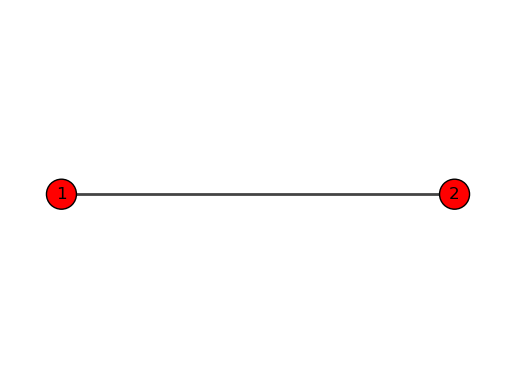

In [30]:
draw_graph(g1)

In [31]:
Statevector(qc1).evolve(np.kron(W.conj().T, W.conj().T)).draw('latex')

<IPython.core.display.Latex object>

In [50]:
qc_theo, gtheo = create_ame_circuit(dim=3, graph_type='star', n=2)
#qc_theo.append(FDAGgate3, [0, 1])

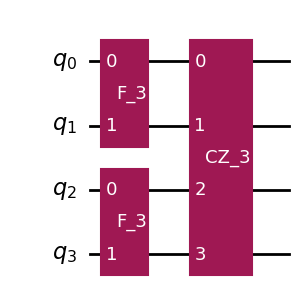

In [33]:
qc_theo.draw('mpl')

In [34]:
Statevector(qc_theo).draw('latex')

<IPython.core.display.Latex object>

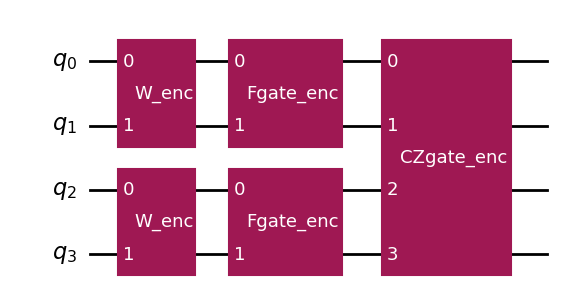

In [35]:
qc1.draw('mpl')

In [36]:
Statevector(qc1).evolve(np.kron(W.conj().T, W.conj().T)).draw('latex')

<IPython.core.display.Latex object>

In [37]:
state_fidelity(Statevector(qc1).evolve(np.kron(W.conj().T, W.conj().T)), Statevector(qc_theo))

0.9999999999999964

In [38]:
from qiskit.transpiler import generate_preset_pass_manager


In [41]:
from qiskit_ibm_runtime.fake_provider import FakeProviderForBackendV2

provider = FakeProviderForBackendV2()
print([b.name for b in provider.backends()])

['fake_algiers', 'fake_almaden', 'fake_armonk', 'fake_athens', 'fake_auckland', 'fake_belem', 'fake_boeblingen', 'fake_bogota', 'fake_brisbane', 'fake_brooklyn', 'fake_burlington', 'fake_cairo', 'fake_cambridge', 'fake_casablanca', 'fake_cusco', 'fake_essex', 'fake_fez', 'fake_fractional', 'fake_geneva', 'fake_guadalupe', 'fake_hanoi', 'fake_jakarta', 'fake_johannesburg', 'fake_kawasaki', 'fake_kolkata', 'fake_kyiv', 'fake_kyoto', 'fake_lagos', 'fake_lima', 'fake_london', 'fake_manhattan', 'fake_manila', 'fake_melbourne', 'fake_marrakesh', 'fake_montreal', 'fake_mumbai', 'fake_nairobi', 'fake_osaka', 'fake_oslo', 'fake_ourense', 'fake_paris', 'fake_peekskill', 'fake_perth', 'fake_prague', 'fake_poughkeepsie', 'fake_quebec', 'fake_quito', 'fake_rochester', 'fake_rome', 'fake_santiago', 'fake_sherbrooke', 'fake_singapore', 'fake_sydney', 'fake_torino', 'fake_toronto', 'fake_valencia', 'fake_vigo', 'fake_washington', 'fake_yorktown']


In [42]:
coupling_map = [
    # poziome
    [0,1],[1,2],[2,3],[3,4],[4,5],[5,6],[6,7],[7,8],[8,9],[9,10],[10,11],[11,12],[12,13],[13,14],[14,15],
    [16,17],[17,18],[18,19],[19,20],[20,21],[21,22],[22,23],[23,24],[24,25],[25,26],[26,27],[27,28],[28,29],[29,30],[30,31],
    [32,33],[33,34],[34,35],[35,36],[36,37],[37,38],[38,39],[39,40],[40,41],[41,42],[42,43],[43,44],[44,45],[45,46],[46,47],
    [48,49],[49,50],[50,51],[51,52],[52,53],[53,54],[54,55],[55,56],[56,57],[57,58],[58,59],[59,60],[60,61],[61,62],[62,63],
    [64,65],[65,66],[66,67],[67,68],[68,69],[69,70],[70,71],[71,72],[72,73],[73,74],[74,75],[75,76],[76,77],[77,78],[78,79],
    [80,81],[81,82],[82,83],[83,84],[84,85],[85,86],[86,87],[87,88],[88,89],[89,90],[90,91],[91,92],[92,93],[93,94],[94,95],
    [96,97],[97,98],[98,99],[99,100],[100,101],[101,102],[102,103],[103,104],[104,105],[105,106],[106,107],[107,108],[108,109],[109,110],[110,111],
    [112,113],[113,114],[114,115],[115,116],[116,117],[117,118],[118,119],[119,120],[120,121],[121,122],[122,123],[123,124],[124,125],[125,126],[126,127],

    # pionowe
    [3,19],[7,23],[11,27],[15,31],
    [17,33],[21,37],[25,41],[29,45],
    [35,51],[39,55],[43,59],[47,63],
    [49,65],[53,69],[57,73],[61,77],
    [67,83],[71,87],[75,91],[79,95],
    [81,97],[85,101],[89,105],[93,109],
    [99,115],[103,119],[107,123],[111,127]
]

In [43]:
from qiskit import transpile

qc_t = transpile(
    qc1,
    basis_gates=["cz", "id", "rx", "rz", "rzz", "sx", "x"],
    coupling_map=coupling_map,
    optimization_level=3
)

In [44]:
qc_t.depth()

259

In [51]:
qc_t2 = transpile(
    qc_theo,
    basis_gates=["cz", "id", "rx", "rz", "rzz", "sx", "x"],
    coupling_map=coupling_map,
    optimization_level=3
)
qc_t2.depth()


31

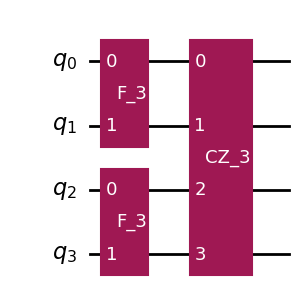

In [52]:
qc_theo.draw('mpl')

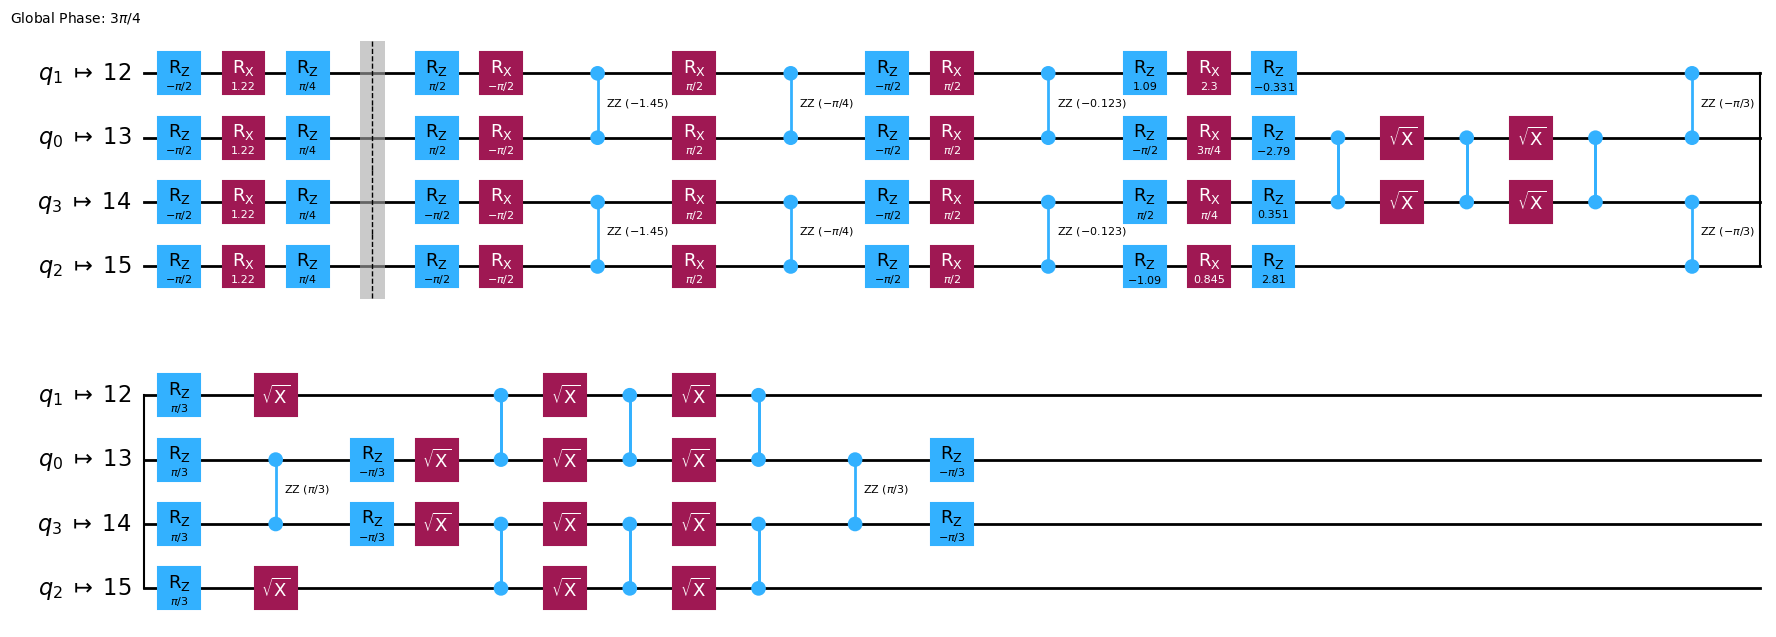

In [53]:
qc_t2.draw('mpl')